In [1]:
import cv2
import numpy as np
import onnxruntime as ort
import os
import yaml
from glob import glob
from pathlib import Path

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

# DATA YAML
DATA_YAML = ROOT / "0_Datasets" / "Male_and_female" /"data.yaml"

# MODELS
DETECTION_ONNX= ROOT / "Models" / "best.onnx"
CLASSIFIER_ONNX  = ROOT / "Models" / "best_CLmodel.onnx"
# =========================

# =========================
# CONFIG
# =========================
IMGSZ = 256
CLS_SIZE = 160

CONF_THRESH = 0.25
NMS_IOU_THRESH = 0.45
MATCH_IOU_THRESH = 0.5

PAD_RATIO = 0.0

CLASS_NAMES = ["Female", "Male"]

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3,1,1)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3,1,1)

# =========================
# IOU
# =========================
def compute_iou(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])

    inter = max(0, xB-xA) * max(0, yB-yA)
    areaA = (a[2]-a[0])*(a[3]-a[1])
    areaB = (b[2]-b[0])*(b[3]-b[1])

    return inter / (areaA + areaB - inter + 1e-9)

# =========================
# LOAD LABELS
# =========================
def load_labels(label_path, w, h):
    boxes, classes = [], []

    if not os.path.exists(label_path):
        return boxes, classes

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls, x, y, bw, bh = map(float, parts)

            x1 = (x - bw/2) * w
            y1 = (y - bh/2) * h
            x2 = (x + bw/2) * w
            y2 = (y + bh/2) * h

            boxes.append([x1, y1, x2, y2])
            classes.append(int(cls))

    return boxes, classes

# =========================
# DATASET PATHS (FIXED)
# =========================
def resolve_test_paths():
    with open(DATA_YAML) as f:
        data = yaml.safe_load(f)

    yaml_dir = os.path.dirname(os.path.abspath(DATA_YAML))

    # =========================
    # Base path (YOLO logic)
    # =========================
    base_path = data.get("path", "")
    if base_path:
        if not os.path.isabs(base_path):
            base_path = os.path.normpath(os.path.join(yaml_dir, base_path))
    else:
        base_path = yaml_dir

    test_path = data.get("test", None)
    if test_path is None:
        raise RuntimeError("No 'test' field in data.yaml")

    # =========================
    # Try multiple resolutions
    # =========================
    candidates = []

    # 1. Absolute path
    if os.path.isabs(test_path):
        candidates.append(test_path)

    # 2. Relative to base_path (YOLO default)
    candidates.append(os.path.normpath(os.path.join(base_path, test_path)))

    # 3. Relative to yaml_dir
    candidates.append(os.path.normpath(os.path.join(yaml_dir, test_path)))

    # 4. Common fallback: dataset/images/test
    candidates.append(os.path.join(base_path, "images", "test"))

    # 5. Common fallback: dataset/test/images
    candidates.append(os.path.join(base_path, "test", "images"))

    # =========================
    # Pick first valid
    # =========================
    test_images = None
    for c in candidates:
        if os.path.exists(c):
            test_images = c
            break

    if test_images is None:
        print("\nTried paths:")
        for c in candidates:
            print(" -", c)
        raise RuntimeError("Could not resolve images path")

    # =========================
    # Labels path
    # =========================
    if "images" in test_images:
        test_labels = test_images.replace("images", "labels")
    else:
        test_labels = os.path.join(os.path.dirname(test_images), "labels")

    # If labels still wrong → try standard structure
    if not os.path.exists(test_labels):
        alt = os.path.join(base_path, "labels", "test")
        if os.path.exists(alt):
            test_labels = alt

    print("\n=== DATASET PATHS (AUTO-FIXED) ===")
    print("YAML dir:", yaml_dir)
    print("Base path:", base_path)
    print("Images:", test_images)
    print("Labels:", test_labels)

    if not os.path.exists(test_images):
        raise RuntimeError(f"Images path not found: {test_images}")

    if not os.path.exists(test_labels):
        raise RuntimeError(f"Labels path not found: {test_labels}")

    return test_images, test_labels

def get_all_images(path):
    files = []
    for ext in ["*.jpg", "*.png", "*.jpeg"]:
        files.extend(glob(os.path.join(path, ext)))
    return files

# =========================
# PREPROCESS
# =========================
def letterbox(img, size):
    h, w = img.shape[:2]
    scale = min(size/w, size/h)

    nw, nh = int(w*scale), int(h*scale)
    resized = cv2.resize(img, (nw, nh))

    canvas = np.full((size, size, 3), 114, dtype=np.uint8)
    top = (size - nh)//2
    left = (size - nw)//2

    canvas[top:top+nh, left:left+nw] = resized
    return canvas, scale, left, top

def preprocess_det(img):
    img, s, px, py = letterbox(img, IMGSZ)
    img = img.astype(np.float32)/255.0
    img = np.transpose(img, (2,0,1))[None]
    return img, s, px, py

def preprocess_cls(crop):
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crop = cv2.resize(crop, (CLS_SIZE, CLS_SIZE))
    crop = crop.astype(np.float32)/255.0
    crop = np.transpose(crop, (2,0,1))
    crop = (crop - MEAN)/STD
    return crop[None]

# =========================
# NMS
# =========================
def nms(boxes, scores, thr):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    scores = np.array(scores)

    order = scores.argsort()[::-1]
    keep = []

    while order.size:
        i = order[0]
        keep.append(i)

        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])
        order = order[1:][ious <= thr]

    return keep

# =========================
# DECODE
# =========================
def decode(out, h, w, scale, px, py):
    out = out[0]

    if out.ndim == 3:
        out = out.squeeze(0)
    if out.shape[0] < out.shape[1]:
        out = out.T

    x,y,bw,bh,conf = out[:,0],out[:,1],out[:,2],out[:,3],out[:,4]

    if np.max(bw) <= 2:
        x1 = (x - bw/2)*IMGSZ
        y1 = (y - bh/2)*IMGSZ
        x2 = (x + bw/2)*IMGSZ
        y2 = (y + bh/2)*IMGSZ
    else:
        x1,y1 = x-bw/2, y-bh/2
        x2,y2 = x+bw/2, y+bh/2

    x1 = (x1 - px)/scale
    x2 = (x2 - px)/scale
    y1 = (y1 - py)/scale
    y2 = (y2 - py)/scale

    boxes = np.stack([x1,y1,x2,y2],1)
    mask = conf > CONF_THRESH

    boxes, conf = boxes[mask], conf[mask]

    keep = nms(boxes, conf, NMS_IOU_THRESH)
    return boxes[keep], conf[keep]

# =========================
# LOAD MODELS
# =========================
det = ort.InferenceSession(DETECTION_ONNX)
det_in = det.get_inputs()[0].name

cls = ort.InferenceSession(CLASSIFIER_ONNX)
cls_in = cls.get_inputs()[0].name
cls_out = cls.get_outputs()[0].name

# =========================
# MAIN
# =========================
img_dir, label_dir = resolve_test_paths()
images = get_all_images(img_dir)

print("\nTotal images:", len(images))

total_gt, detected, correct = 0, 0, 0

for i, img_path in enumerate(images):

    frame = cv2.imread(img_path)
    if frame is None:
        continue

    h, w = frame.shape[:2]

    base = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(label_dir, base + ".txt")

    gt_boxes, gt_cls = load_labels(label_path, w, h)

    # DEBUG (first 3 images only)
    if i < 3:
        print("\nIMG:", img_path)
        print("LABEL:", label_path)
        print("GT count:", len(gt_boxes))

    total_gt += len(gt_boxes)

    inp, s, px, py = preprocess_det(frame)
    out = det.run(None, {det_in: inp})

    pred_boxes, _ = decode(out, h, w, s, px, py)

    matched = set()

    for pb in pred_boxes:
        best_iou, best_idx = 0, -1

        for j, gb in enumerate(gt_boxes):
            if j in matched:
                continue

            iou = compute_iou(pb, gb)
            if iou > best_iou:
                best_iou, best_idx = iou, j

        if best_iou >= MATCH_IOU_THRESH:
            detected += 1
            matched.add(best_idx)

            crop = frame[int(pb[1]):int(pb[3]), int(pb[0]):int(pb[2])]
            if crop.size == 0:
                continue

            inp_cls = preprocess_cls(crop)
            logits = cls.run([cls_out], {cls_in: inp_cls})[0][0]

            pred = int(np.argmax(logits))

            if pred == gt_cls[best_idx]:
                correct += 1

# =========================
# RESULTS
# =========================
print("\n===== CASCADE EVALUATION =====")
print("Total GT:", total_gt)
print("Detected:", detected)
print("Correct:", correct)

recall = detected / total_gt if total_gt else 0
cascade = correct / total_gt if total_gt else 0
cls_acc = correct / detected if detected else 0

print(f"Detection Recall: {recall:.4f}")
print(f"Cascade Accuracy: {cascade:.4f}")
print(f"Cls|Det Accuracy: {cls_acc:.4f}")


=== DATASET PATHS (AUTO-FIXED) ===
YAML dir: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female
Base path: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female
Images: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female\test\images
Labels: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female\test\labels

Total images: 235

IMG: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female\test\images\DSCN5037_JPG.rf.0b7c3334bc2c7d89ce1b332b6edcd295.jpg
LABEL: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female\test\labels\DSCN5037_JPG.rf.0b7c3334bc2c7d89ce1b332b6edcd295.txt
GT count: 4

IMG: c:\Users\lucas\Desktop\Trabajo Fi


=== PATH DEBUG ===
YAML dir: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2)\2_\dataset
Base path: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2)\2_\dataset
Test field: ../test/images
Candidates:
 - c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2)\2_\test\images
 - c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2)\2_\test\images
 - c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2)\2_\dataset\images\test
 - c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2)\2_\dataset\test\images

=== FINAL PATHS ===
Images: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2)\2_\dataset\test\images
Labels: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2)\2_\dataset\test\labels
Total images: 235


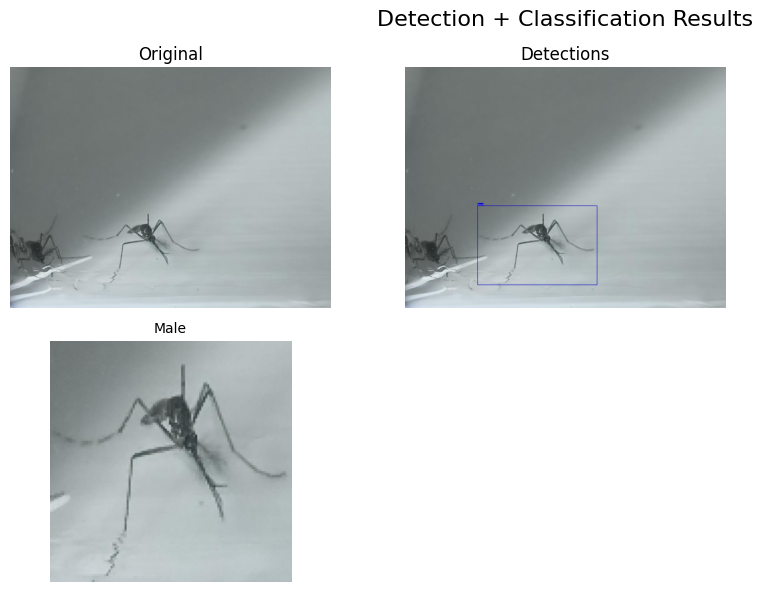

Saved: results_visual\result_0.png


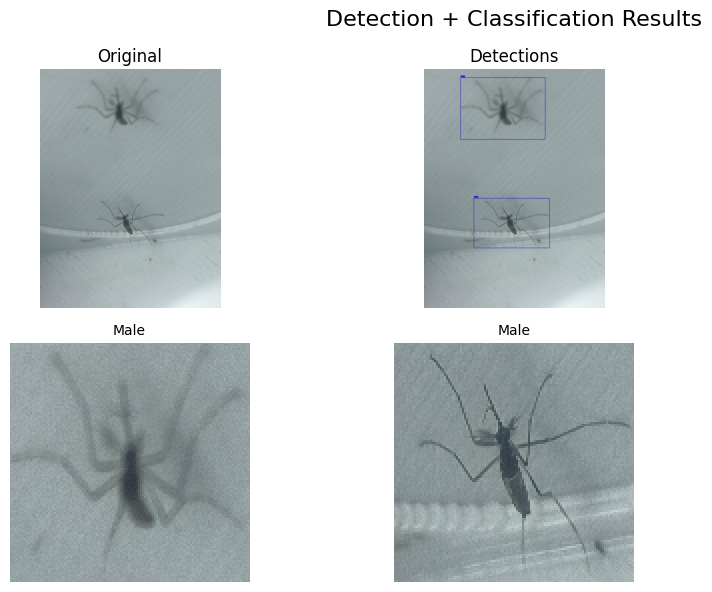

Saved: results_visual\result_1.png


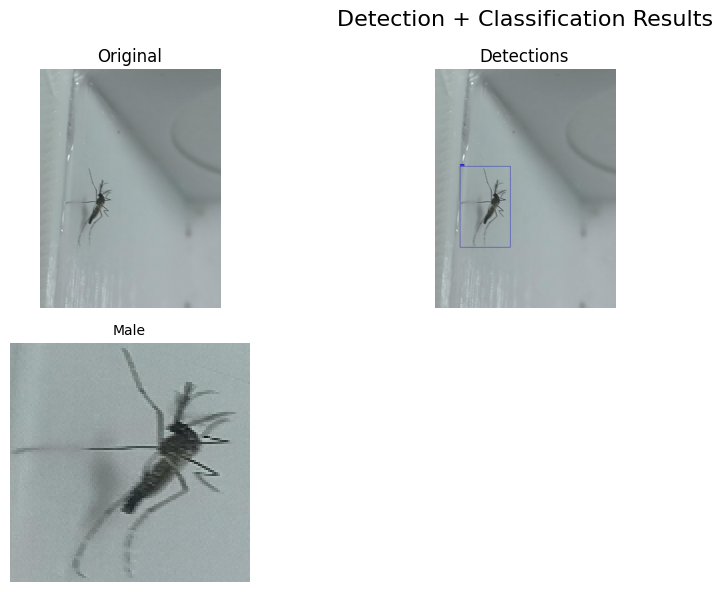

Saved: results_visual\result_2.png


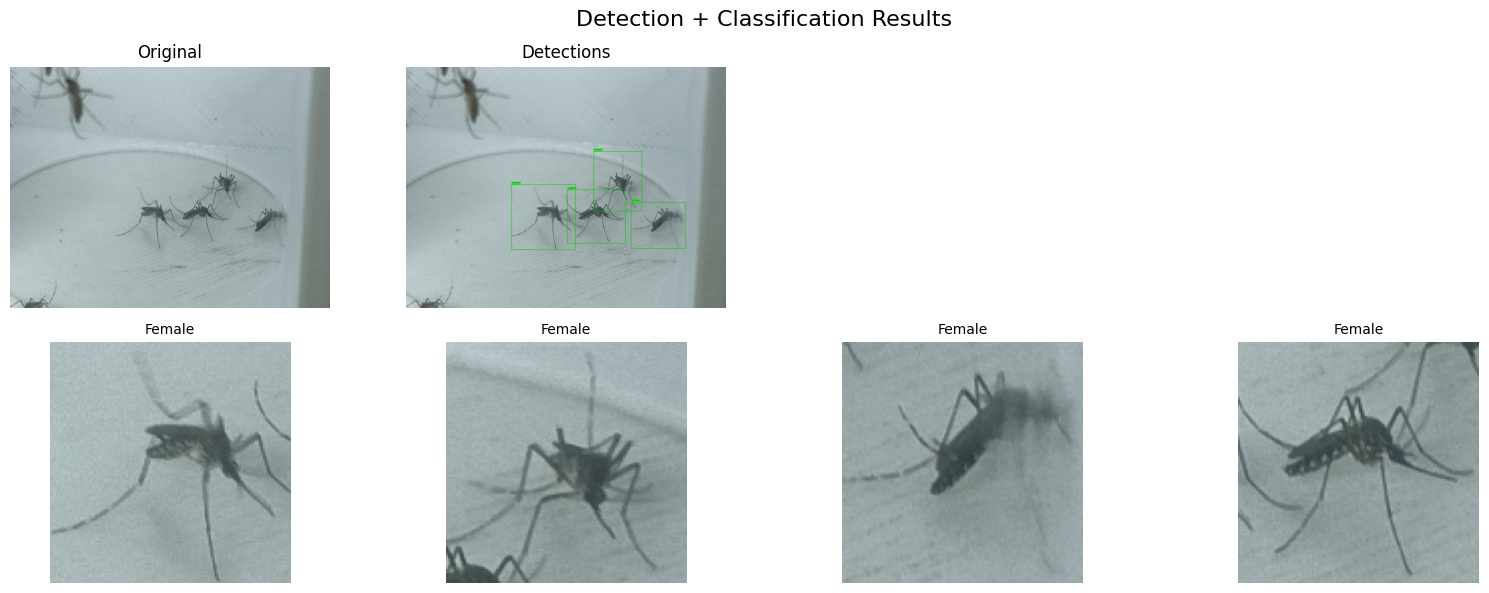

Saved: results_visual\result_3.png


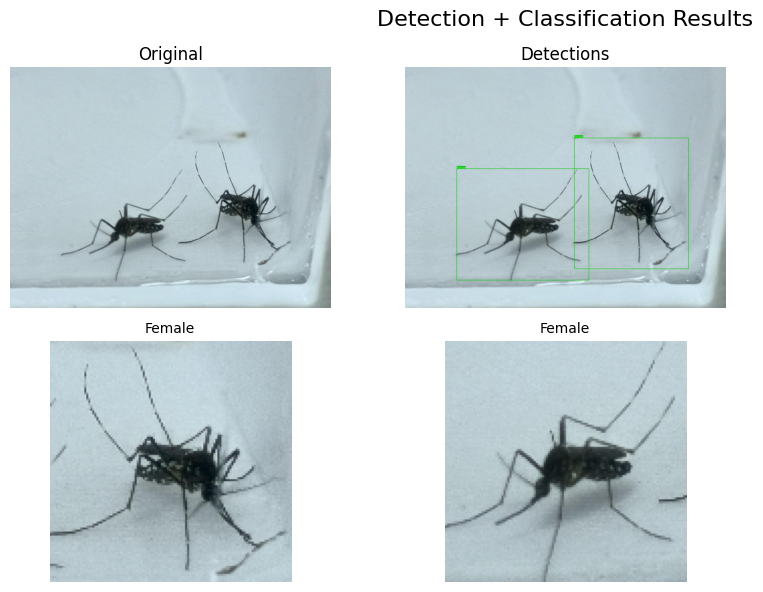

Saved: results_visual\result_4.png


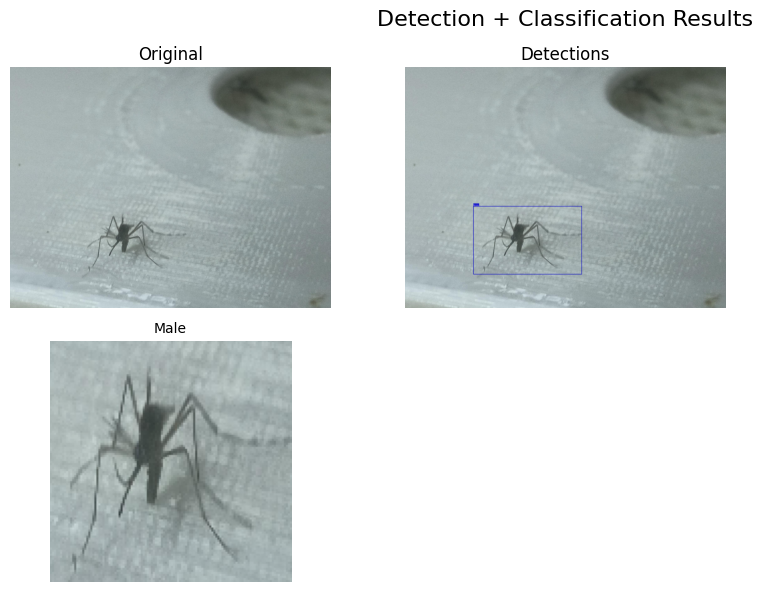

Saved: results_visual\result_5.png


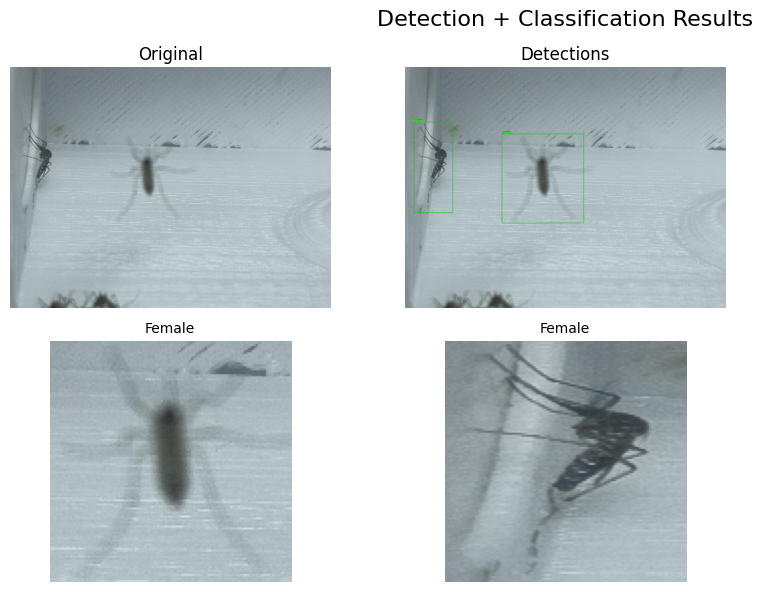

Saved: results_visual\result_6.png


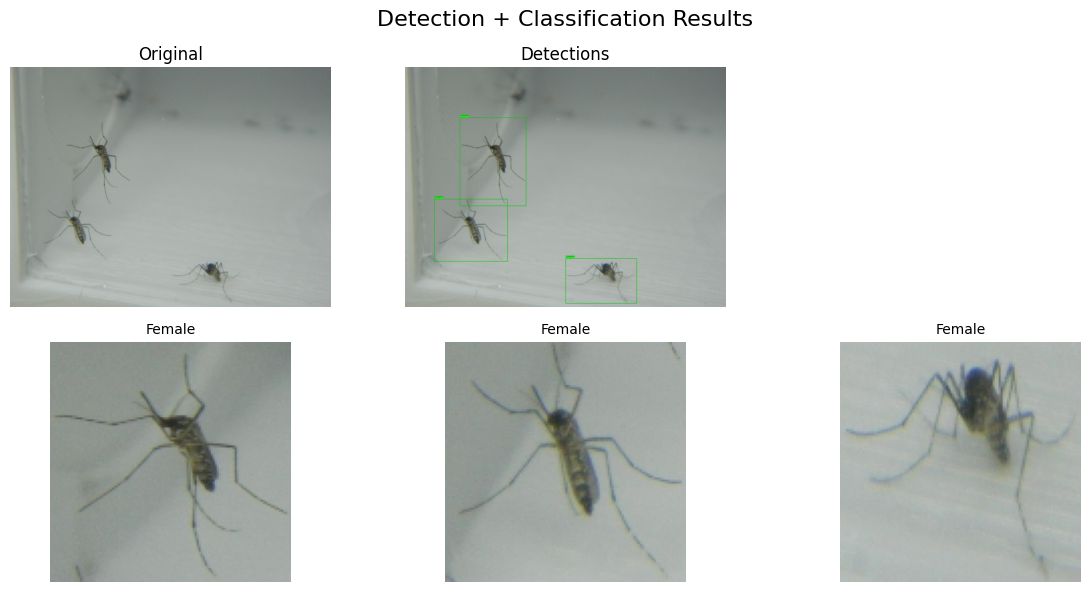

Saved: results_visual\result_7.png


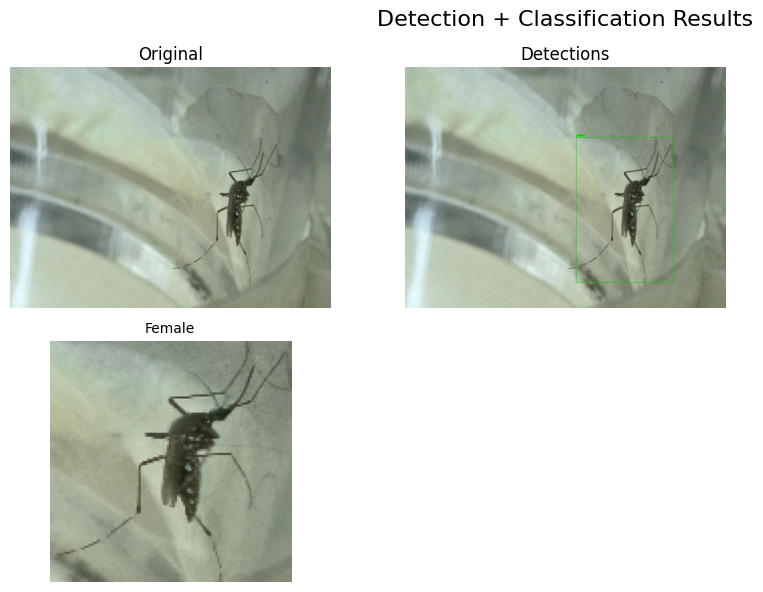

Saved: results_visual\result_8.png


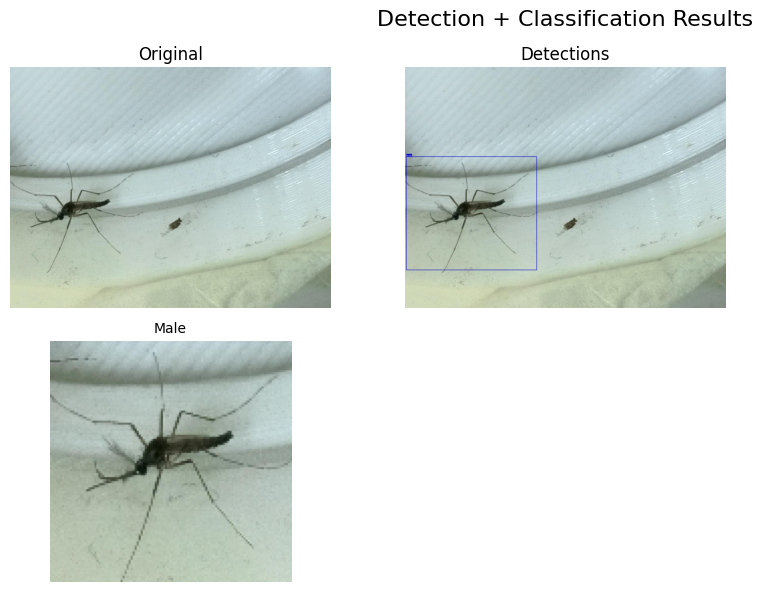

Saved: results_visual\result_9.png


In [2]:
import cv2
import numpy as np
import onnxruntime as ort
import os
import yaml
from glob import glob
import random
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
DETECTION_ONNX = "best.onnx"
CLASSIFIER_ONNX = "best_CLmodel_fixed.onnx"
DATA_YAML = "dataset/data.yaml"

OUTPUT_DIR = "results_visual"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMGSZ = 256
CLS_SIZE = 160

CONF_THRESH = 0.25
NMS_IOU_THRESH = 0.45

CLASS_NAMES = ["Female", "Male"]

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3,1,1)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3,1,1)

MAX_CROPS = 6  # avoid overcrowding

# =========================
# DATASET PATHS
# =========================
def resolve_test_paths():
    with open(DATA_YAML) as f:
        data = yaml.safe_load(f)

    yaml_dir = os.path.dirname(os.path.abspath(DATA_YAML))

    base_path = data.get("path", "")
    if base_path:
        if not os.path.isabs(base_path):
            base_path = os.path.normpath(os.path.join(yaml_dir, base_path))
    else:
        base_path = yaml_dir

    test_path = data.get("test", "")

    # =========================
    # Build ALL candidates
    # =========================
    candidates = []

    # 1. Absolute
    if os.path.isabs(test_path):
        candidates.append(test_path)

    # 2. Relative to base_path (YOLO standard)
    candidates.append(os.path.normpath(os.path.join(base_path, test_path)))

    # 3. Relative to yaml dir
    candidates.append(os.path.normpath(os.path.join(yaml_dir, test_path)))

    # 4. Common structures
    candidates.append(os.path.join(base_path, "images", "test"))
    candidates.append(os.path.join(base_path, "test", "images"))

    # =========================
    # DEBUG PRINT
    # =========================
    print("\n=== PATH DEBUG ===")
    print("YAML dir:", yaml_dir)
    print("Base path:", base_path)
    print("Test field:", test_path)
    print("Candidates:")
    for c in candidates:
        print(" -", c)

    # =========================
    # Select valid path
    # =========================
    test_images = None
    for c in candidates:
        if c and os.path.exists(c):
            test_images = c
            break

    if test_images is None:
        raise RuntimeError("Could not resolve dataset paths")

    # =========================
    # Labels path
    # =========================
    if "images" in test_images:
        test_labels = test_images.replace("images", "labels")
    else:
        test_labels = os.path.join(os.path.dirname(test_images), "labels")

    # fallback
    if not os.path.exists(test_labels):
        alt = os.path.join(base_path, "labels", "test")
        if os.path.exists(alt):
            test_labels = alt

    print("\n=== FINAL PATHS ===")
    print("Images:", test_images)
    print("Labels:", test_labels)

    if not os.path.exists(test_images):
        raise RuntimeError(f"Images not found: {test_images}")

    if not os.path.exists(test_labels):
        raise RuntimeError(f"Labels not found: {test_labels}")

    return test_images, test_labels

def get_all_images(path):
    files = []
    for ext in ["*.jpg", "*.png", "*.jpeg"]:
        files.extend(glob(os.path.join(path, ext)))
    return files

# =========================
# PREPROCESS
# =========================
def letterbox(img, size):
    h, w = img.shape[:2]
    scale = min(size/w, size/h)

    nw, nh = int(w*scale), int(h*scale)
    resized = cv2.resize(img, (nw, nh))

    canvas = np.full((size, size, 3), 114, dtype=np.uint8)
    top = (size - nh)//2
    left = (size - nw)//2

    canvas[top:top+nh, left:left+nw] = resized
    return canvas, scale, left, top

def preprocess_det(img):
    img, s, px, py = letterbox(img, IMGSZ)
    img = img.astype(np.float32)/255.0
    img = np.transpose(img, (2,0,1))[None]
    return img, s, px, py

def preprocess_cls(crop):
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crop = cv2.resize(crop, (CLS_SIZE, CLS_SIZE))
    crop = crop.astype(np.float32)/255.0
    crop = np.transpose(crop, (2,0,1))
    crop = (crop - MEAN)/STD
    return crop[None]

# =========================
# NMS + DECODE
# =========================
def compute_iou(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    areaA = (a[2]-a[0])*(a[3]-a[1])
    areaB = (b[2]-b[0])*(b[3]-b[1])
    return inter / (areaA + areaB - inter + 1e-9)

def nms(boxes, scores, thr):
    if len(boxes) == 0:
        return []
    boxes = np.array(boxes)
    scores = np.array(scores)
    order = scores.argsort()[::-1]
    keep = []
    while order.size:
        i = order[0]
        keep.append(i)
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])
        order = order[1:][ious <= thr]
    return keep

def decode(out, h, w, scale, px, py):
    out = out[0]
    if out.ndim == 3:
        out = out.squeeze(0)
    if out.shape[0] < out.shape[1]:
        out = out.T

    x,y,bw,bh,conf = out[:,0],out[:,1],out[:,2],out[:,3],out[:,4]

    if np.max(bw) <= 2:
        x1 = (x - bw/2)*IMGSZ
        y1 = (y - bh/2)*IMGSZ
        x2 = (x + bw/2)*IMGSZ
        y2 = (y + bh/2)*IMGSZ
    else:
        x1,y1 = x-bw/2, y-bh/2
        x2,y2 = x+bw/2, y+bh/2

    x1 = (x1 - px)/scale
    x2 = (x2 - px)/scale
    y1 = (y1 - py)/scale
    y2 = (y2 - py)/scale

    boxes = np.stack([x1,y1,x2,y2],1)
    mask = conf > CONF_THRESH

    boxes, conf = boxes[mask], conf[mask]
    keep = nms(boxes, conf, NMS_IOU_THRESH)

    return boxes[keep], conf[keep]

# =========================
# VISUALIZATION (IMPROVED)
# =========================
def visualize_result(img, boxes, preds, save_path):

    img_draw = img.copy()
    crops = []

    for box, pred in zip(boxes, preds):
        x1, y1, x2, y2 = map(int, box)

        color = (0,200,0) if pred == 0 else (200,0,0)
        label = CLASS_NAMES[pred]

        # bbox
        cv2.rectangle(img_draw, (x1,y1), (x2,y2), color, 2)

        # label with background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img_draw, (x1, y1-th-5), (x1+tw, y1), color, -1)
        cv2.putText(img_draw, label, (x1, y1-2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        crop = img[y1:y2, x1:x2]
        if crop.size != 0:
            crop = cv2.resize(crop, (120,120))
            crops.append((crop, label))

    crops = crops[:MAX_CROPS]

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_draw_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)

    # Layout
    n = len(crops)
    cols = max(3, n)
    fig = plt.figure(figsize=(4*cols, 6))

    # Title
    fig.suptitle("Detection + Classification Results", fontsize=16)

    # Original
    ax1 = plt.subplot(2, cols, 1)
    ax1.imshow(img_rgb)
    ax1.set_title("Original")
    ax1.axis("off")

    # Detection
    ax2 = plt.subplot(2, cols, 2)
    ax2.imshow(img_draw_rgb)
    ax2.set_title("Detections")
    ax2.axis("off")

    # Crops grid
    for i, (crop, label) in enumerate(crops):
        ax = plt.subplot(2, cols, cols + i + 1)
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(label, fontsize=10)
        ax.axis("off")

    plt.tight_layout()

    # Save
    plt.savefig(save_path, dpi=200)
    plt.show()  # show in Jupyter
    plt.close()

# =========================
# LOAD MODELS
# =========================
det = ort.InferenceSession(DETECTION_ONNX)
det_in = det.get_inputs()[0].name

cls = ort.InferenceSession(CLASSIFIER_ONNX)
cls_in = cls.get_inputs()[0].name
cls_out = cls.get_outputs()[0].name

# =========================
# MAIN
# =========================
img_dir, _ = resolve_test_paths()
images = get_all_images(img_dir)

print("Total images:", len(images))

images = random.sample(images, min(10, len(images)))

for i, img_path in enumerate(images):

    frame = cv2.imread(img_path)
    if frame is None:
        continue

    h, w = frame.shape[:2]

    inp, s, px, py = preprocess_det(frame)
    out = det.run(None, {det_in: inp})

    pred_boxes, _ = decode(out, h, w, s, px, py)

    preds = []

    for pb in pred_boxes:
        x1, y1, x2, y2 = map(int, pb)
        crop = frame[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        inp_cls = preprocess_cls(crop)
        logits = cls.run([cls_out], {cls_in: inp_cls})[0][0]

        preds.append(int(np.argmax(logits)))

    save_path = os.path.join(OUTPUT_DIR, f"result_{i}.png")
    visualize_result(frame, pred_boxes[:len(preds)], preds, save_path)

    print(f"Saved: {save_path}")

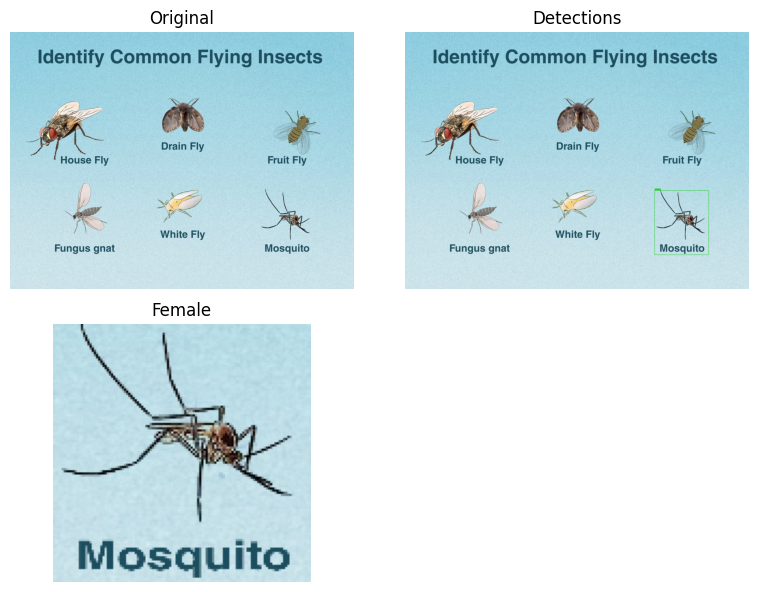

Saved result to: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\3_CASCADE\Output_Images\result.png


In [2]:
import cv2
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

# IMAGE TEST PATH
IMAGE_PATH = ROOT / "3_CASCADE" / "Exam_Images" / "exam7.jpg" # <-- PUT YOUR IMAGE HERE

# IMAGE OUTPUT
OUTPUT_PATH = ROOT / "3_CASCADE" / "Output_Images" / "result.png"

# MODELS
DETECTION_ONNX= ROOT / "Models" / "best.onnx"
CLASSIFIER_ONNX  = ROOT / "Models" / "best_CLmodel.onnx"
# =========================


# =========================
# CONFIG
# =========================
IMGSZ = 256
CLS_SIZE = 160

CONF_THRESH = 0.25
NMS_IOU_THRESH = 0.45

CLASS_NAMES = ["Female", "Male"]

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3,1,1)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3,1,1)

MAX_CROPS = 6


# =========================
# PREPROCESS
# =========================
def letterbox(img, size):
    h, w = img.shape[:2]
    scale = min(size/w, size/h)

    nw, nh = int(w*scale), int(h*scale)
    resized = cv2.resize(img, (nw, nh))

    canvas = np.full((size, size, 3), 114, dtype=np.uint8)
    top = (size - nh)//2
    left = (size - nw)//2

    canvas[top:top+nh, left:left+nw] = resized
    return canvas, scale, left, top

def preprocess_det(img):
    img, s, px, py = letterbox(img, IMGSZ)
    img = img.astype(np.float32)/255.0
    img = np.transpose(img, (2,0,1))[None]
    return img, s, px, py

def preprocess_cls(crop):
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crop = cv2.resize(crop, (CLS_SIZE, CLS_SIZE))
    crop = crop.astype(np.float32)/255.0
    crop = np.transpose(crop, (2,0,1))
    crop = (crop - MEAN)/STD
    return crop[None]


# =========================
# NMS + DECODE
# =========================
def compute_iou(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    areaA = (a[2]-a[0])*(a[3]-a[1])
    areaB = (b[2]-b[0])*(b[3]-b[1])
    return inter / (areaA + areaB - inter + 1e-9)

def nms(boxes, scores, thr):
    if len(boxes) == 0:
        return []
    boxes = np.array(boxes)
    scores = np.array(scores)
    order = scores.argsort()[::-1]

    keep = []
    while order.size:
        i = order[0]
        keep.append(i)
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])
        order = order[1:][ious <= thr]
    return keep

def decode(out, h, w, scale, px, py):
    out = out[0]

    if out.ndim == 3:
        out = out.squeeze(0)
    if out.shape[0] < out.shape[1]:
        out = out.T

    x,y,bw,bh,conf = out[:,0],out[:,1],out[:,2],out[:,3],out[:,4]

    if np.max(bw) <= 2:
        x1 = (x - bw/2)*IMGSZ
        y1 = (y - bh/2)*IMGSZ
        x2 = (x + bw/2)*IMGSZ
        y2 = (y + bh/2)*IMGSZ
    else:
        x1,y1 = x-bw/2, y-bh/2
        x2,y2 = x+bw/2, y+bh/2

    x1 = (x1 - px)/scale
    x2 = (x2 - px)/scale
    y1 = (y1 - py)/scale
    y2 = (y2 - py)/scale

    boxes = np.stack([x1,y1,x2,y2],1)

    mask = conf > CONF_THRESH
    boxes, conf = boxes[mask], conf[mask]

    keep = nms(boxes, conf, NMS_IOU_THRESH)

    return boxes[keep], conf[keep]


# =========================
# VISUALIZATION
# =========================
def visualize_result(img, boxes, preds, save_path):

    img_draw = img.copy()
    crops = []

    for box, pred in zip(boxes, preds):
        x1, y1, x2, y2 = map(int, box)

        color = (0,200,0) if pred == 0 else (200,0,0)
        label = CLASS_NAMES[pred]

        cv2.rectangle(img_draw, (x1,y1), (x2,y2), color, 2)

        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img_draw, (x1, y1-th-5), (x1+tw, y1), color, -1)
        cv2.putText(img_draw, label, (x1, y1-2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        crop = img[y1:y2, x1:x2]
        if crop.size != 0:
            crop = cv2.resize(crop, (120,120))
            crops.append((crop, label))

    crops = crops[:MAX_CROPS]

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_draw_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)

    cols = max(3, len(crops))
    fig = plt.figure(figsize=(4*cols, 6))

    ax1 = plt.subplot(2, cols, 1)
    ax1.imshow(img_rgb)
    ax1.set_title("Original")
    ax1.axis("off")

    ax2 = plt.subplot(2, cols, 2)
    ax2.imshow(img_draw_rgb)
    ax2.set_title("Detections")
    ax2.axis("off")

    for i, (crop, label) in enumerate(crops):
        ax = plt.subplot(2, cols, cols + i + 1)
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(label)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    plt.close()


# =========================
# LOAD MODELS
# =========================
det = ort.InferenceSession(DETECTION_ONNX)
det_in = det.get_inputs()[0].name

cls = ort.InferenceSession(CLASSIFIER_ONNX)
cls_in = cls.get_inputs()[0].name
cls_out = cls.get_outputs()[0].name


# =========================
# MAIN (SINGLE IMAGE)
# =========================
frame = cv2.imread(IMAGE_PATH)

if frame is None:
    raise RuntimeError(f"Image not found: {IMAGE_PATH}")

h, w = frame.shape[:2]

# ---- Detection ----
inp, s, px, py = preprocess_det(frame)
out = det.run(None, {det_in: inp})

boxes, _ = decode(out, h, w, s, px, py)

# ---- Classification ----
preds = []

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    crop = frame[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    inp_cls = preprocess_cls(crop)
    logits = cls.run([cls_out], {cls_in: inp_cls})[0][0]

    preds.append(int(np.argmax(logits)))

# ---- Visualization ----
visualize_result(frame, boxes[:len(preds)], preds, OUTPUT_PATH)

print(f"Saved result to: {OUTPUT_PATH}")

In [3]:
"""
evaluate_cascade.py
────────────────────────────────────────────────────────────────
Evalúa el pipeline cascada (detector ONNX + clasificador ONNX)
sobre un dataset YOLO (.yaml) y produce métricas completas.

Uso:
    python evaluate_cascade.py

Salida:
    - Reporte en consola
    - results/metrics_report.txt
    - results/confusion_matrix.png
    - results/metrics_bar.png
    - results/metrics_summary.json
────────────────────────────────────────────────────────────────
"""
import cv2
import numpy as np
import onnxruntime as ort
import os, json, time, yaml
from pathlib import Path
from collections import defaultdict

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

# DATA YAML
DATA_YAML = ROOT / "0_Datasets" / "Male_and_female" /"data.yaml"

# MODELS
DETECTION_ONNX= ROOT / "Models" / "best.onnx"
CLASSIFIER_ONNX  = ROOT / "Models" / "best_CLmodel.onnx"


# ─────────────────────────────────────────────
# CONFIG  (ajusta rutas si es necesario)
# ─────────────────────────────────────────────
SPLIT            = "test"          # "train" | "val" | "test"

IMGSZ            = 256
CLS_SIZE         = 160
CONF_THRESH      = 0.25
NMS_IOU_THRESH   = 0.45
PAD_RATIO        = 0.0
IOU_MATCH_THRESH = 0.5            # IoU mínimo para considerar un TP en detección

CLASS_NAMES      = ["Female", "Male"]
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3,1,1)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3,1,1)

OUT_DIR = Path("results")
OUT_DIR.mkdir(exist_ok=True)


# ═══════════════════════════════════════════════════════════════
#  UTILIDADES DE IMAGEN / PREPROCESAMIENTO
# ═══════════════════════════════════════════════════════════════

def letterbox(image, new_size=256, color=(114, 114, 114)):
    h, w = image.shape[:2]
    scale = min(new_size / w, new_size / h)
    nw, nh = int(w * scale), int(h * scale)
    image_resized = cv2.resize(image, (nw, nh))
    new_image = np.full((new_size, new_size, 3), color, dtype=np.uint8)
    top  = (new_size - nh) // 2
    left = (new_size - nw) // 2
    new_image[top:top+nh, left:left+nw] = image_resized
    return new_image, scale, left, top


def preprocess_det(frame):
    img, scale, pad_x, pad_y = letterbox(frame, IMGSZ)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))[None, ...]
    return img, scale, pad_x, pad_y


def preprocess_cls(crop):
    img = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (CLS_SIZE, CLS_SIZE))
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    img = (img - MEAN) / STD
    return np.expand_dims(img, axis=0).astype(np.float32)


# ═══════════════════════════════════════════════════════════════
#  NMS + DECODE
# ═══════════════════════════════════════════════════════════════

def nms(boxes, scores, iou_threshold=0.45):
    if len(boxes) == 0:
        return []
    x1, y1, x2, y2 = boxes.T
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)
        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]
    return keep


def decode_output(output, frame_h, frame_w, scale, pad_x, pad_y):
    out = output[0]
    if out.ndim == 3:
        out = out.squeeze(0)
    if out.shape[0] < out.shape[1]:
        out = out.T
    x, y, w, h, scores = out[:,0], out[:,1], out[:,2], out[:,3], out[:,4]
    if np.max(w) <= 2.0:
        x1 = (x - w/2) * IMGSZ;  y1 = (y - h/2) * IMGSZ
        x2 = (x + w/2) * IMGSZ;  y2 = (y + h/2) * IMGSZ
    else:
        x1, y1 = x - w/2, y - h/2
        x2, y2 = x + w/2, y + h/2
    x1 = (x1 - pad_x) / scale;  x2 = (x2 - pad_x) / scale
    y1 = (y1 - pad_y) / scale;  y2 = (y2 - pad_y) / scale
    boxes = np.stack([x1, y1, x2, y2], axis=1)
    boxes[:, 0] = np.clip(boxes[:, 0], 0, frame_w)
    boxes[:, 1] = np.clip(boxes[:, 1], 0, frame_h)
    boxes[:, 2] = np.clip(boxes[:, 2], 0, frame_w)
    boxes[:, 3] = np.clip(boxes[:, 3], 0, frame_h)
    mask = scores > CONF_THRESH
    boxes, scores = boxes[mask], scores[mask]
    if len(boxes) == 0:
        return boxes, scores
    keep = nms(boxes, scores, NMS_IOU_THRESH)
    return boxes[keep], scores[keep]


def crop_with_padding(image, box, pad=0.0):
    h, w = image.shape[:2]
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    pad_x, pad_y = bw * pad, bh * pad
    x1 = int(max(0, x1 - pad_x));  y1 = int(max(0, y1 - pad_y))
    x2 = int(min(w, x2 + pad_x));  y2 = int(min(h, y2 + pad_y))
    return image[y1:y2, x1:x2]


# ═══════════════════════════════════════════════════════════════
#  CARGA DE LABELS YOLO
# ═══════════════════════════════════════════════════════════════

def load_yolo_labels(label_path, img_w, img_h):
    """
    Retorna lista de dicts: {class_id, x1, y1, x2, y2}
    YOLO formato: class cx cy w h  (normalizado)
    """
    annotations = []
    if not os.path.exists(label_path):
        return annotations
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            annotations.append(dict(class_id=cls_id, x1=x1, y1=y1, x2=x2, y2=y2))
    return annotations


def iou_box(a, b):
    """IoU entre dos boxes (x1,y1,x2,y2)."""
    ix1 = max(a[0], b[0]);  iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]);  iy2 = min(a[3], b[3])
    iw = max(0, ix2 - ix1);  ih = max(0, iy2 - iy1)
    inter = iw * ih
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    union = area_a + area_b - inter + 1e-9
    return inter / union


# ═══════════════════════════════════════════════════════════════
#  CARGA DE MODELOS
# ═══════════════════════════════════════════════════════════════

print("Cargando modelos ONNX…")
det_session  = ort.InferenceSession(DETECTION_ONNX,  providers=["CPUExecutionProvider"])
det_input    = det_session.get_inputs()[0].name

cls_session  = ort.InferenceSession(CLASSIFIER_ONNX, providers=["CPUExecutionProvider"])
cls_input    = cls_session.get_inputs()[0].name
cls_output_n = cls_session.get_outputs()[0].name
print("Modelos cargados.\n")


# ═══════════════════════════════════════════════════════════════
#  RESOLUCIÓN DEL DATASET  (robusta para cualquier estructura YOLO)
# ═══════════════════════════════════════════════════════════════

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

yaml_dir  = Path(DATA_YAML).parent.resolve()
split_val = data_cfg[SPLIT]   # e.g. "test/images", "../test/images", ruta absoluta

# ── Resolver img_dir ──────────────────────────────────────────
candidate_img = Path(split_val)
if not candidate_img.is_absolute():
    candidate_img = (yaml_dir / split_val).resolve()

if candidate_img.exists():
    img_dir = candidate_img
elif (candidate_img / "images").exists():
    img_dir = candidate_img / "images"
else:
    # Último intento: buscar carpeta 'images' bajo yaml_dir/SPLIT
    fallback = yaml_dir / SPLIT / "images"
    if fallback.exists():
        img_dir = fallback
    else:
        raise FileNotFoundError(
            f"No se encontró la carpeta de imágenes.\n"
            f"  Probado: {candidate_img}\n"
            f"  Probado: {candidate_img / 'images'}\n"
            f"  Probado: {fallback}\n"
            f"  Revisa DATA_YAML y SPLIT."
        )

# ── Resolver lbl_dir ─────────────────────────────────────────
# Intento 1 — estructura más común:  .../split/images  →  .../split/labels
lbl_dir = img_dir.parent / "labels"

# Intento 2 — estructura con nivel extra:  .../root/images/split  →  .../root/labels/split
if not lbl_dir.exists():
    lbl_dir = img_dir.parent.parent / "labels" / img_dir.name

# Intento 3 — reemplazar la parte "images" de la ruta por "labels"
if not lbl_dir.exists():
    parts = list(img_dir.parts)
    if "images" in parts:
        idx = len(parts) - 1 - parts[::-1].index("images")   # último "images"
        parts[idx] = "labels"
        lbl_dir = Path(*parts)

if not lbl_dir.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de labels.\n"
        f"  img_dir   : {img_dir}\n"
        f"  Último intento: {lbl_dir}\n"
        f"  Verifica la estructura de tu dataset."
    )

print(f"Split        : {SPLIT}")
print(f"Imágenes     : {img_dir}")
print(f"Labels       : {lbl_dir}")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted([p for p in img_dir.iterdir()
                      if p.suffix.lower() in image_extensions])

print(f"Imágenes encontradas: {len(image_paths)}\n")
if len(image_paths) == 0:
    raise FileNotFoundError(f"No se encontraron imágenes en: {img_dir}")


# ═══════════════════════════════════════════════════════════════
#  BUCLE PRINCIPAL DE EVALUACIÓN
# ═══════════════════════════════════════════════════════════════

NC = len(CLASS_NAMES)

# Detección
det_tp = np.zeros(NC, dtype=int)
det_fp = np.zeros(NC, dtype=int)
det_fn = np.zeros(NC, dtype=int)

# Clasificación (solo sobre detecciones matched)
cls_confusion = np.zeros((NC, NC), dtype=int)    # [gt, pred]
cls_scores_per_class = defaultdict(list)           # gt_class → [conf_correct, ...]

total_images    = 0
total_det_gt    = 0
total_det_pred  = 0
images_no_det   = 0
inference_times = []

for img_path in image_paths:
    lbl_path = lbl_dir / (img_path.stem + ".txt")

    frame = cv2.imread(str(img_path))
    if frame is None:
        print(f"  [WARN] No se pudo leer: {img_path.name}")
        continue

    h, w = frame.shape[:2]
    gt_anns = load_yolo_labels(str(lbl_path), w, h)
    total_images   += 1
    total_det_gt   += len(gt_anns)

    # ── DETECCIÓN ──────────────────────────────────────────
    t0 = time.perf_counter()
    inp, scale, px, py = preprocess_det(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    raw_out = det_session.run(None, {det_input: inp})
    pred_boxes, pred_scores = decode_output(raw_out, h, w, scale, px, py)
    t_det = time.perf_counter() - t0

    # ── MATCHING detector vs GT ────────────────────────────
    gt_matched   = [False] * len(gt_anns)
    pred_matched = [False] * len(pred_boxes)

    for gi, gt in enumerate(gt_anns):
        gt_box = [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
        best_iou, best_pi = 0, -1
        for pi, pbox in enumerate(pred_boxes):
            if pred_matched[pi]:
                continue
            iou = iou_box(gt_box, list(pbox))
            if iou > best_iou:
                best_iou, best_pi = iou, pi
        if best_iou >= IOU_MATCH_THRESH:
            gt_matched[gi]        = True
            pred_matched[best_pi] = True
            det_tp[gt["class_id"]] += 1
        else:
            det_fn[gt["class_id"]] += 1

    for pi, matched in enumerate(pred_matched):
        if not matched:
            det_fp[0] += 1   # FP genérico (detector sin GT correspondiente)

    total_det_pred += len(pred_boxes)
    if len(pred_boxes) == 0:
        images_no_det += 1

    # ── CLASIFICACIÓN sobre detecciones matched ────────────
    t0 = time.perf_counter()
    for gi, gt in enumerate(gt_anns):
        if not gt_matched[gi]:
            continue   # GT no detectado → no entra en métricas de clasificación

        gt_box = [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
        best_iou, best_pi = 0, -1
        for pi, pbox in enumerate(pred_boxes):
            iou = iou_box(gt_box, list(pbox))
            if iou > best_iou:
                best_iou, best_pi = iou, pi

        if best_pi < 0:
            continue

        crop = crop_with_padding(frame, pred_boxes[best_pi], PAD_RATIO)
        if crop.size == 0:
            continue

        inp_cls = preprocess_cls(crop)
        logits  = cls_session.run([cls_output_n], {cls_input: inp_cls})[0][0]
        logits -= np.max(logits)
        probs    = np.exp(logits) / np.sum(np.exp(logits))
        pred_cls = int(np.argmax(probs))
        conf     = float(probs[pred_cls])

        gt_cls = gt["class_id"]
        cls_confusion[gt_cls, pred_cls] += 1
        cls_scores_per_class[gt_cls].append(conf if pred_cls == gt_cls else 1 - conf)

    t_cls = time.perf_counter() - t0
    inference_times.append(t_det + t_cls)

print(f"\nEvaluación completada: {total_images} imágenes procesadas.")


# ═══════════════════════════════════════════════════════════════
#  CÁLCULO DE MÉTRICAS
# ═══════════════════════════════════════════════════════════════

def safe_div(a, b):
    return a / b if b > 0 else 0.0

# ── Métricas de DETECCIÓN ──────────────────────────────────────
det_precision = np.array([safe_div(det_tp[c], det_tp[c] + det_fp[c]) for c in range(NC)])
det_recall    = np.array([safe_div(det_tp[c], det_tp[c] + det_fn[c]) for c in range(NC)])
det_f1        = np.array([safe_div(2*det_precision[c]*det_recall[c],
                                   det_precision[c]+det_recall[c]) for c in range(NC)])
det_prec_macro = det_precision.mean()
det_rec_macro  = det_recall.mean()
det_f1_macro   = det_f1.mean()

# ── Métricas de CLASIFICACIÓN ──────────────────────────────────
cls_tp_per = np.diag(cls_confusion)
cls_fp_per = cls_confusion.sum(axis=0) - cls_tp_per
cls_fn_per = cls_confusion.sum(axis=1) - cls_tp_per

cls_precision = np.array([safe_div(cls_tp_per[c], cls_tp_per[c]+cls_fp_per[c]) for c in range(NC)])
cls_recall    = np.array([safe_div(cls_tp_per[c], cls_tp_per[c]+cls_fn_per[c]) for c in range(NC)])
cls_f1        = np.array([safe_div(2*cls_precision[c]*cls_recall[c],
                                   cls_precision[c]+cls_recall[c]) for c in range(NC)])

total_cls_instances = cls_confusion.sum()
cls_accuracy   = safe_div(cls_tp_per.sum(), total_cls_instances)
cls_prec_macro = cls_precision.mean()
cls_rec_macro  = cls_recall.mean()
cls_f1_macro   = cls_f1.mean()

# Weighted averages
weights = cls_confusion.sum(axis=1)   # support por clase
total_w = weights.sum()
cls_prec_w = safe_div((cls_precision * weights).sum(), total_w)
cls_rec_w  = safe_div((cls_recall    * weights).sum(), total_w)
cls_f1_w   = safe_div((cls_f1        * weights).sum(), total_w)

# ── Pipeline end-to-end ────────────────────────────────────────
e2e_correct  = sum(cls_confusion[c, c] for c in range(NC))
e2e_accuracy = safe_div(e2e_correct, total_det_gt)

avg_inference_ms = (np.mean(inference_times) * 1000) if inference_times else 0
fps_est          = 1000 / avg_inference_ms if avg_inference_ms > 0 else 0


# ═══════════════════════════════════════════════════════════════
#  REPORTE EN CONSOLA
# ═══════════════════════════════════════════════════════════════

SEP = "═" * 65

def pct(v): return f"{v*100:.2f}%"

report_lines = []

def p(line=""):
    print(line)
    report_lines.append(line)

p(SEP)
p(f"  REPORTE DE MÉTRICAS — Pipeline Cascada ONNX")
p(f"  Split: {SPLIT.upper()}   |   {total_images} imágenes")
p(SEP)

p(f"\n{'─'*65}")
p(f"  DETECCIÓN  (IoU threshold = {IOU_MATCH_THRESH})")
p(f"{'─'*65}")
p(f"  {'Clase':<12} {'TP':>6} {'FP':>6} {'FN':>6}  {'Prec':>8} {'Recall':>8} {'F1':>8}")
p(f"  {'─'*60}")
for c in range(NC):
    p(f"  {CLASS_NAMES[c]:<12} {det_tp[c]:>6} {det_fp[c]:>6} {det_fn[c]:>6}  "
      f"{pct(det_precision[c]):>8} {pct(det_recall[c]):>8} {pct(det_f1[c]):>8}")
p(f"  {'─'*60}")
p(f"  {'MACRO':<12} {'':>6} {'':>6} {'':>6}  "
  f"{pct(det_prec_macro):>8} {pct(det_rec_macro):>8} {pct(det_f1_macro):>8}")
p(f"\n  GT total: {total_det_gt}  |  Predicciones: {total_det_pred}  "
  f"|  Imágenes sin detección: {images_no_det}")

p(f"\n{'─'*65}")
p(f"  CLASIFICACIÓN  (sobre instancias detectadas = {total_cls_instances})")
p(f"{'─'*65}")
p(f"  {'Clase':<12} {'TP':>6} {'FP':>6} {'FN':>6}  {'Prec':>8} {'Recall':>8} {'F1':>8} {'Support':>9}")
p(f"  {'─'*65}")
for c in range(NC):
    p(f"  {CLASS_NAMES[c]:<12} {cls_tp_per[c]:>6} {cls_fp_per[c]:>6} {cls_fn_per[c]:>6}  "
      f"{pct(cls_precision[c]):>8} {pct(cls_recall[c]):>8} {pct(cls_f1[c]):>8} {weights[c]:>9}")
p(f"  {'─'*65}")
p(f"  {'MACRO':<40} {pct(cls_prec_macro):>8} {pct(cls_rec_macro):>8} {pct(cls_f1_macro):>8}")
p(f"  {'WEIGHTED':<40} {pct(cls_prec_w):>8} {pct(cls_rec_w):>8} {pct(cls_f1_w):>8}")
p(f"\n  Accuracy clasificador : {pct(cls_accuracy)}")

p(f"\n{'─'*65}")
p(f"  MATRIZ DE CONFUSIÓN (clasificación)")
p(f"{'─'*65}")
p(f"  {'':>14}" + "".join(f"  Pred:{CLASS_NAMES[c]:<8}" for c in range(NC)))
for r in range(NC):
    row_str = f"  GT:{CLASS_NAMES[r]:<11}" + "".join(f"  {cls_confusion[r,c]:>13}" for c in range(NC))
    p(row_str)

p(f"\n{'─'*65}")
p(f"  PIPELINE END-TO-END")
p(f"{'─'*65}")
p(f"  Accuracy E2E (detectado Y clasificado correcto / total GT) : {pct(e2e_accuracy)}")
p(f"  Tiempo de inferencia promedio : {avg_inference_ms:.1f} ms/imagen")
p(f"  FPS estimado                  : {fps_est:.1f}")
p(SEP)


# ═══════════════════════════════════════════════════════════════
#  GUARDAR REPORTE TEXTO
# ═══════════════════════════════════════════════════════════════

report_path = OUT_DIR / "metrics_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
print(f"\nReporte guardado en: {report_path}")


# ═══════════════════════════════════════════════════════════════
#  GUARDAR JSON
# ═══════════════════════════════════════════════════════════════

summary = {
    "split": SPLIT,
    "total_images": total_images,
    "detection": {
        "iou_threshold": IOU_MATCH_THRESH,
        "per_class": {
            CLASS_NAMES[c]: {
                "TP": int(det_tp[c]), "FP": int(det_fp[c]), "FN": int(det_fn[c]),
                "precision": round(float(det_precision[c]), 4),
                "recall":    round(float(det_recall[c]),    4),
                "f1":        round(float(det_f1[c]),        4),
            } for c in range(NC)
        },
        "macro": {
            "precision": round(float(det_prec_macro), 4),
            "recall":    round(float(det_rec_macro),  4),
            "f1":        round(float(det_f1_macro),   4),
        }
    },
    "classification": {
        "total_instances": int(total_cls_instances),
        "accuracy": round(float(cls_accuracy), 4),
        "confusion_matrix": cls_confusion.tolist(),
        "per_class": {
            CLASS_NAMES[c]: {
                "TP": int(cls_tp_per[c]), "FP": int(cls_fp_per[c]), "FN": int(cls_fn_per[c]),
                "precision": round(float(cls_precision[c]), 4),
                "recall":    round(float(cls_recall[c]),    4),
                "f1":        round(float(cls_f1[c]),        4),
                "support":   int(weights[c]),
            } for c in range(NC)
        },
        "macro":    {"precision": round(float(cls_prec_macro), 4),
                     "recall":    round(float(cls_rec_macro),  4),
                     "f1":        round(float(cls_f1_macro),   4)},
        "weighted": {"precision": round(float(cls_prec_w), 4),
                     "recall":    round(float(cls_rec_w),  4),
                     "f1":        round(float(cls_f1_w),   4)},
    },
    "end_to_end": {
        "accuracy": round(float(e2e_accuracy), 4),
        "avg_inference_ms": round(avg_inference_ms, 2),
        "fps": round(fps_est, 2),
    }
}

json_path = OUT_DIR / "metrics_summary.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"JSON guardado en: {json_path}")


# ═══════════════════════════════════════════════════════════════
#  PLOTS  (matplotlib)
# ═══════════════════════════════════════════════════════════════

try:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("[INFO] matplotlib no instalado; omitiendo gráficas.")

if HAVE_MPL:
    # ── Confusion matrix ────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    cm_norm = cls_confusion.astype(float) / (cls_confusion.sum(axis=1, keepdims=True) + 1e-9)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(NC)); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
    ax.set_yticks(range(NC)); ax.set_yticklabels(CLASS_NAMES, fontsize=11)
    ax.set_xlabel("Predicción", fontsize=12)
    ax.set_ylabel("Ground Truth", fontsize=12)
    ax.set_title(f"Confusion Matrix — Clasificador\n(Split: {SPLIT})", fontsize=13)
    for r in range(NC):
        for c in range(NC):
            color = "white" if cm_norm[r, c] > 0.6 else "black"
            ax.text(c, r, f"{cls_confusion[r,c]}\n({cm_norm[r,c]*100:.1f}%)",
                    ha="center", va="center", fontsize=10, color=color)
    plt.tight_layout()
    cm_path = OUT_DIR / "confusion_matrix.png"
    fig.savefig(cm_path, dpi=150)
    plt.close(fig)
    print(f"Confusion matrix guardada en: {cm_path}")

    # ── Bar chart métricas ──────────────────────────────────────
    metrics_names = ["Det Precision", "Det Recall", "Det F1",
                     "Cls Precision", "Cls Recall", "Cls F1", "Cls Accuracy", "E2E Accuracy"]
    metrics_vals  = [det_prec_macro, det_rec_macro, det_f1_macro,
                     cls_prec_macro, cls_rec_macro, cls_f1_macro, cls_accuracy, e2e_accuracy]
    colors = ["#4C8BE2"]*3 + ["#E2814C"]*4 + ["#4CBE7A"]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(metrics_names, [v*100 for v in metrics_vals],
                  color=colors, edgecolor="white", width=0.6)
    for bar, val in zip(bars, metrics_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, 115)
    ax.set_ylabel("Score (%)", fontsize=12)
    ax.set_title(f"Métricas del Pipeline Cascada ONNX — Split: {SPLIT}", fontsize=13)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    patches = [
        mpatches.Patch(color="#4C8BE2", label="Detección (macro)"),
        mpatches.Patch(color="#E2814C", label="Clasificación (macro)"),
        mpatches.Patch(color="#4CBE7A", label="End-to-End"),
    ]
    ax.legend(handles=patches, loc="lower right", fontsize=9)
    plt.xticks(rotation=20, ha="right", fontsize=9)
    plt.tight_layout()
    bar_path = OUT_DIR / "metrics_bar.png"
    fig.savefig(bar_path, dpi=150)
    plt.close(fig)
    print(f"Bar chart guardado en: {bar_path}")

print("\n¡Evaluación completa!")

Cargando modelos ONNX…
Modelos cargados.

Split        : test
Imágenes     : C:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female\test\images
Labels       : C:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Male_and_female\test\labels
Imágenes encontradas: 235


Evaluación completada: 235 imágenes procesadas.
═════════════════════════════════════════════════════════════════
  REPORTE DE MÉTRICAS — Pipeline Cascada ONNX
  Split: TEST   |   235 imágenes
═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  DETECCIÓN  (IoU threshold = 0.5)
─────────────────────────────────────────────────────────────────
  Clase            TP     FP     FN      Prec   Recall       F1
  ────────────────────────────────────────────────────────────
  Female          152    151     85    50.17%   64.14%   56.30%
  Male  